<a href="https://colab.research.google.com/github/Aishwarya-114/TNSIF--AIML/blob/main/EDA%26Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is the process of analyzing and summarizing a cleaned dataset to understand its patterns, distributions, relationships, and characteristics before building Machine Learning models.

###EDA helps us answer questions like:

- What does the data tell us?
- What patterns are present?
- Which variables are important?
- Are there any trends or relationships?

####Data Preprocessing
1. Understand the Business Problem
        
2. Understand the Dataset
        
3. Perform Descriptive Statistics
        
4. Analyze Individual Features (Univariate Analysis)
        
5. Analyze Relationships Between Features (Bivariate Analysis)
        
6. Analyze Multiple Features Together (Multivariate Analysis)
        
7. Detect Outliers
        
8. Create Visualizations
        
9. Draw Insights & Conclusions
        
10. Prepare Data for Machine Learning

# **Outliers**
An outlier is a value that is unusually high or unusually low compared to the rest of the data.


##Why Do Outliers Occur?

Outliers may occur because of:

1. Human data entry mistakes
2. Measurement errors
3. Experimental errors
4. Natural variations
5. Fraudulent activities

**Procedure**

An outlier is a data value that is significantly different from the other values in the dataset.

Example:

25, 28, 30, 32, 35, 36, 38, 250

Here, 250 is an outlier because it is much larger than the other values.

**Step 2: Arrange the Data**

Before finding outliers, arrange the data in ascending order.

**Example**

10 15 18 20 22 24 26 30 35

**Step 3: Calculate Quartiles**

Quartiles divide the dataset into four equal parts.

Minimum

↓

Q1 (25%)

↓

Q2 (Median - 50%)

↓

Q3 (75%)

↓

Maximum
Q1 (First Quartile)
25% of the data lies below Q1.
Q2 (Median)
50% of the data lies below the median.
Q3 (Third Quartile)
75% of the data lies below Q3.

**Step 4: Find the Quartiles**

For a dataset arranged in ascending order:

10 15 18 20 22 24 26 30 35

Q1 = 18

Q2 = 22

Q3 = 30

(In Python, these are calculated automatically using the quantile() function.)

**Step 5: Calculate IQR (Interquartile Range)**

Formula
IQR = Q3 - Q1

Example

Q3 = 30

Q1 = 18

IQR = 30 − 18

IQR = 12

**Step 6: Calculate the Lower Limit**

Formula
Lower Limit = Q1 − (1.5 × IQR)

Example

Lower Limit = 18 − (1.5 × 12)

Lower Limit = 18 − 18

Lower Limit = 0

**Step 7: Calculate the Upper Limit**

Formula
Upper Limit = Q3 + (1.5 × IQR)

Example

Upper Limit = 30 + (1.5 × 12)

Upper Limit = 30 + 18

Upper Limit = 48

**Step 8: Identify Outliers**

Now compare every value in the dataset with the limits.

Rule
If Value < Lower Limit

OR

If Value > Upper Limit

↓

It is an Outlier

**Step 9: Handle Outliers**

After detecting outliers, we can handle them using different methods.

**Method 1**

Remove the outlier.

Delete the row containing the outlier.

**Method 2**

Replace the outlier.

Replace with Mean

or

Replace with Median

#**Task:**
You are given height_weight.csv file which contains heights and weights of 1000 people. Dataset is taken from here, https://www.kaggle.com/mustafaali96/weight-height

You need to do this,

(1) Load this csv in pandas dataframe and first plot histograms for height and weight parameters

(2) Using IQR detect weight outliers and print them

(3) Using IQR, detect height outliers and print them

(4) replace the outliers with mean and median  and print the dataset


# (1) Load this csv in pandas dataframe and first plot histograms for height and weight parameters

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/weight-height.csv")
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [ ]:
df.describe()


,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


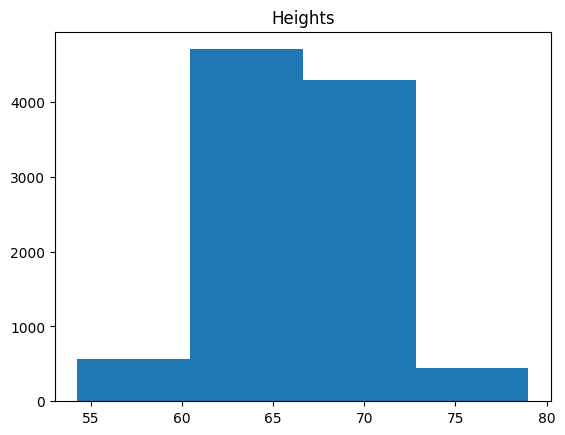

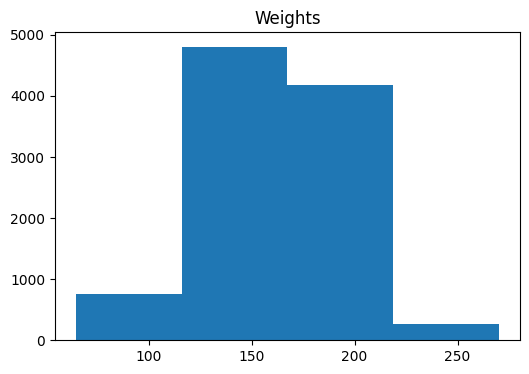

In [ ]:

plt.hist(df['Height'], bins=4)
plt.title("Heights")
plt.show()


plt.figure(figsize=(6,4))
plt.hist(df['Weight'], bins=4)
plt.title("Weights")
plt.show()

## (2) Using IQR detect weight outliers and print them

In [ ]:
Q1_W = df['Weight'].quantile(0.25)
Q3_W = df['Weight'].quantile(0.75)
Q1_W, Q3_W

(np.float64(135.8180513055015), np.float64(187.16952486868348))

In [ ]:
IQR = Q3_W - Q1_W
IQR

np.float64(51.35147356318197)

In [ ]:
lower_limit = Q1_W - 1.5*IQR
upper_limit = Q3_W + 1.5*IQR
lower_limit, upper_limit

(np.float64(58.79084096072856), np.float64(264.19673521345646))

In [ ]:
weight_outliers = df.loc[(df.Weight< lower_limit) | (df.Weight> upper_limit),['Gender','Weight']]
weight_outliers

,Gender,Weight
0,Male,241.893563
1,Male,162.310473
2,Male,212.740856
3,Male,220.042470
4,Male,206.349801
...,...,...
9995,Female,136.777454
9996,Female,170.867906
9997,Female,128.475319
9998,Female,163.852461


## (3) Using IQR, detect height outliers and print them

In [ ]:
Q1_H = df.Height.quantile(0.25)
Q3_H = df.Height.quantile(0.75)
Q1_H, Q3_H

(np.float64(63.505620481218955), np.float64(69.1742617268347))

In [ ]:
IQR = Q3_H - Q1_H
IQR

np.float64(5.668641245615746)

In [ ]:
lower_limit = Q1_H - 1.5*IQR
upper_limit = Q3_H + 1.5*IQR
lower_limit, upper_limit

(np.float64(55.00265861279534), np.float64(77.67722359525831))

In [ ]:
Height_outliers = df.loc[(df.Height < lower_limit) | (df.Height > upper_limit), ['Gender','Height']]
Height_outliers

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
7294,Female,54.873728
9285,Female,54.263133


## (4) replace the outliers with mean and median and print the dataset

In [ ]:
weight_mean = df.Weight.mean()
height_mean = df.Height.mean()

In [ ]:
df_mean.loc[(df_mean['Weight'] < lower_limit) | (df_mean['Weight'] > upper_limit), 'Weight'] = weight_mean
df_mean.loc[(df_mean['Height'] < lower_limit) | (df_mean['Height'] > upper_limit), 'Height'] = height_mean
df_mean

,Gender,Height,Weight
0,Male,73.847017,161.440357
1,Male,68.781904,161.440357
2,Male,74.110105,161.440357
3,Male,71.730978,161.440357
4,Male,69.881796,161.440357
...,...,...,...
9995,Female,66.172652,161.440357
9996,Female,67.067155,161.440357
9997,Female,63.867992,161.440357
9998,Female,69.034243,161.440357


In [ ]:
weight_median = df.Weight.median()
height_median = df.Height.median()

In [ ]:

df_median.loc[(df_median.Weight< lower_limit) | (df_median.Weight> upper_limit), 'Weight'] = weight_median
df_median.loc[(df_median.Height< lower_limit) | (df_median.Height> upper_limit), 'Height'] = height_median

df_median

,Gender,Height,Weight
0,Male,73.847017,161.212928
1,Male,68.781904,161.212928
2,Male,74.110105,161.212928
3,Male,71.730978,161.212928
4,Male,69.881796,161.212928
...,...,...,...
9995,Female,66.172652,161.212928
9996,Female,67.067155,161.212928
9997,Female,63.867992,161.212928
9998,Female,69.034243,161.212928
